In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../../../.."))
sys.path.insert(0, project_root)

# Load modules

from src.utils.data_partition import temporal_split
from src.conformal.mapie_per_cell import apply_conformal_mapie_per_cell

from src.utils.spatial_processing import predictions_to_grid, grid_to_dataframe
from src.evaluation.evaluation_cp import base_analysis, compute_weighted_metric_summary
from src.evaluation.visualize_basic_analysis import plot_temporal_metrics_summary, plot_metric_radar_by_hotspot_type, plot_temporal_metrics_over_time, plot_weighted_cwc_series

from src.utils.visualization import plot_geospatial_data_maps, plot_cp

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load global config
config_path = os.path.join("../../../", "config.json")
with open(config_path, 'r') as f:
    config = json.load(f)

# Define hotspot method from config
hotspot_percentage = config["evaluation"]["hotspot_percentage"]
hotspot_method = config["evaluation"].get("hotspot_definition", "by_cells")  # default


# Partition data
partition_config = config["data_partition"]
days_per_month = 30
train_days = partition_config["train_months"] * days_per_month
calibration_days = partition_config["calibration_months"] * days_per_month
test_days = partition_config["test_months"] * days_per_month

# Paths
data_dir = "../../../data/real_data/Chicago/"
map_path = os.path.join(data_dir, "beat_to_coord_map.json")

path_dir="../../../results/models/dummy_data/Chicago/"
naive_model = joblib.load(os.path.join(path_dir,"naive_cell_model.pkl"))

# Define path
data_path = "../../../../../../uncertainty-informed-data/real_data/Chicago"
geometry_name = "police_beats.geojson"
geometry_path = os.path.join(data_path, geometry_name)

save_folder = Path("../../../results/figures/dummy/Chicago_split")
os.makedirs(save_folder,exist_ok=True)

# Load data
gdf = gpd.read_file(os.path.abspath(geometry_path))

# Load
df=pd.read_csv("../../../data/dummy_data/chicago_dummy.csv")
with open(map_path) as f:
    beat_to_coord_map = json.load(f)

coord_to_beat_map = {tuple(v): k for k, v in beat_to_coord_map.items()}

rows, cols = tuple(df[["row","col"]].max()+1)
grid_size = (rows, cols)

df_train, df_calib, df_test = temporal_split(df, train_days, train_days + calibration_days, train_days + calibration_days + test_days)

# Define features
features = ["timestep", "row", "col"]
target = "count"

X_train, y_train = df_train[features].copy(), df_train[target].copy()

X_cal = df_calib[features].copy()
y_cal = df_calib[target].copy()

X_test = df_test[features].copy()
y_test = df_test[target].copy()

alpha = 0.1 ## significance level

weights = {
    "Both": 0.4,
    "GT-only": 0.4,
    "Pred-only": 0.1,
    "Neither": 0.1
}


In [3]:
callable(naive_model)

False

In [3]:
# Apply conformal prediction per cell using pre-trained model
grid_pred, y_min, y_max, grid_true = apply_conformal_mapie_per_cell(
    X_train, y_train,
    X_cal, y_cal,
    X_test, y_test,
    base_estimator=naive_model,
    alpha=alpha,
    conformalizer="split",
    grid_size=grid_size
)

pred_day = np.random.randint(0, test_days)

df_true = grid_to_dataframe(grid_true[pred_day], coord_to_beat_map, value_name="Real Crimes")
df_pred = grid_to_dataframe(grid_pred[pred_day], coord_to_beat_map, value_name="Prediction Crimes")
df_min = grid_to_dataframe(y_min[pred_day], coord_to_beat_map, value_name="Prediction Crimes")
df_max = grid_to_dataframe(y_max[pred_day], coord_to_beat_map, value_name="Prediction Crimes")


(
    in_interval,
    widths,
    error,
    overall_hs_class_grid,
    time_step_hs_class_grid,
    result_cwc,
    result_mwi,
    coverage_results,
    width_results,
    error_results,
    y_true_results,
    y_pred_results
) = base_analysis(y_min, y_max, grid_pred, grid_true, grid_size, alpha, hotspot_percentage, eta=8, ref=6)
WH_CWC = compute_weighted_metric_summary(result_cwc, weights=weights)


Processing rows: 100%|██████████| 17/17 [00:00<00:00, 17.16it/s]


In [4]:
print("Overall Metrics:")
print(f"Coverage Width-Based Criterion: {result_cwc['global']:.2f}")
print(f"Mean Winkler Interval Score: {result_mwi['global']:.2f}" )
print(f"Coverage Score: {coverage_results['global']*100:.2f}% ± {in_interval.std()*100:.2f}%")
print(f"Mean Width Score: {width_results['global']:.2f} ± {widths.std():.2f}")
print(f"Distance to Interval (when no cover): {error_results['global']:.2f} ± {np.nanstd(error):.2f}")

Overall Metrics:
Coverage Width-Based Criterion: 0.42
Mean Winkler Interval Score: 4.77
Coverage Score: 94.43% ± 22.93%
Mean Width Score: 3.47 ± 1.38
Distance to Interval (when no cover): 1.17 ± 0.73


In [5]:
df_CWS=grid_to_dataframe(result_cwc["per_cell"], coord_to_beat_map, value_name="Coverage Width-Based Criterion").set_index(["row","col","beat"])
CWS_average, CWS_std = result_cwc["per_cell"].mean(), result_cwc["per_cell"].std()

df_MWI=grid_to_dataframe(result_mwi["per_cell"], coord_to_beat_map, value_name="Mean Winkler Interval Score").set_index(["row","col","beat"])
MWI_average, MWI_std = result_mwi["per_cell"].mean(), result_mwi["per_cell"].std()

df_coverage_score=grid_to_dataframe(coverage_results["per_cell"], coord_to_beat_map, value_name="Coverage Score").set_index(["row","col","beat"])
coverage_average, coverage_std = coverage_results["per_cell"].mean()*100, coverage_results["per_cell"].std()*100
df_coverage_score["Coverage Score"]*=100

df_width=grid_to_dataframe(width_results["per_cell"], coord_to_beat_map, value_name="Mean Width Score").set_index(["row","col","beat"])
width_average, width_std = width_results["per_cell"].mean(), width_results["per_cell"].std()

distance_interval_average, distance_interval_std = np.nanmean(error_results["per_cell"]), np.nanstd(error_results["per_cell"])

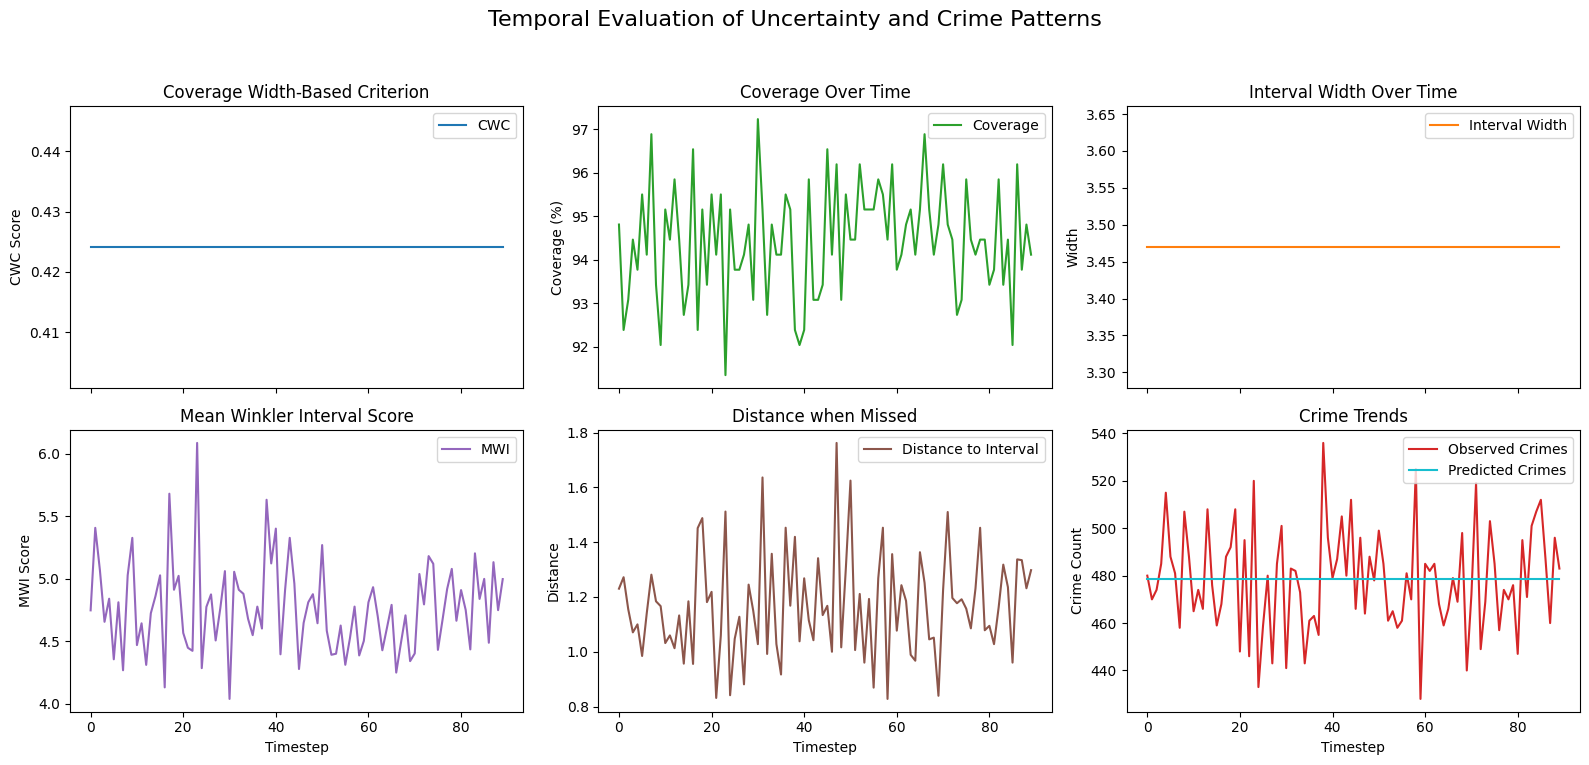

Pearson Correlation with Total Observed Crimes:
CWC Score               : ρ = nan
Coverage (%)            : ρ = -0.445
Interval Width          : ρ = nan
MWI                     : ρ = 0.478
Distance when Missed    : ρ = 0.171
Predicted Crime Count   : ρ = nan

##################################################
Time Series Metrics (Mean ± Std):
CWC                     : 0.42 ± 0.00
MWI                     : 4.77 ± 0.36
Coverage (%)            : 94.43% ± 1.25%
Interval Width          : 3.47 ± 0.00
Distance when Missed    : 1.17 ± 0.19
Observed Crimes         : 478.28 ± 21.50
Predicted Crimes        : 478.52 ± 0.00


In [6]:
plot_temporal_metrics_summary(
    result_cwc,
    coverage_results,
    width_results,
    result_mwi,
    error_results,
    y_true_results,
    y_pred_results,
    save_path= save_folder / "overall_temporal_eval.pdf"
)

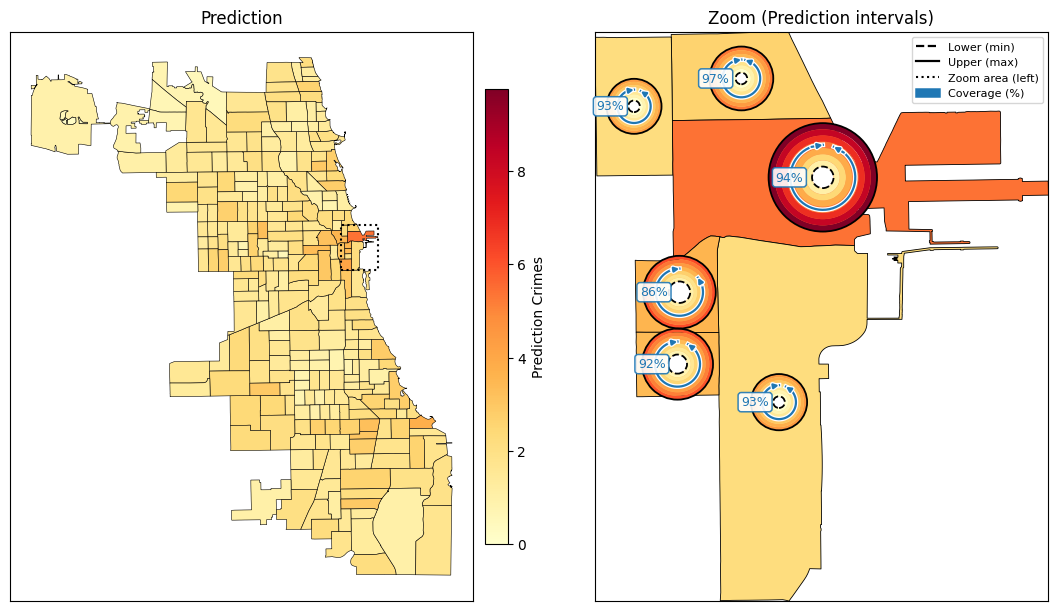

In [7]:
global_vmin = min(df_min["Prediction Crimes"].min(),
                  df_pred["Prediction Crimes"].min(),
                  df_max["Prediction Crimes"].min())
global_vmax = max(df_min["Prediction Crimes"].max(),
                  df_pred["Prediction Crimes"].max(),
                  df_max["Prediction Crimes"].max())

cfg = plot_cp(
    gdf_base=gdf[["beat_num","geometry"]],
    df_pred=df_pred, df_min=df_min, df_max=df_max,
    df_cov=df_coverage_score.reset_index(), cov_col="Coverage Score",
    cmap="YlOrRd", vmin=global_vmin, vmax=global_vmax,
    zoom_on="beat", zoom_value=None, neighbors_k=6,
    inner_ls="--", outer_ls="-", white_inner=True,
    banded=True, band_steps=7,
    figsize=(12, 6), width_ratios=(1.1, 1.0),
    gradient_steps=64, rings_alpha=1,
    colorbar_label="Prediction Crimes", span_factor=0.4,
    title_left="Prediction", title_right="Zoom (Prediction intervals)",
    scale_circles=0.6, r0_ratio=0.12, min_thickness_policy="outward",
    min_visible_ratio=0.12,
    annotate_values=False, show_coverage=True,         
    coverage_place="inside",  
    coverage_color="#1f77b4", legend_loc="best",reuse_config=None,
    save_path=save_folder / "cp_basic.pdf"
)

In [8]:
import json
with open(save_folder.parent / 'cfg_cp_plot.json', 'w') as fp:
    json.dump(cfg, fp)

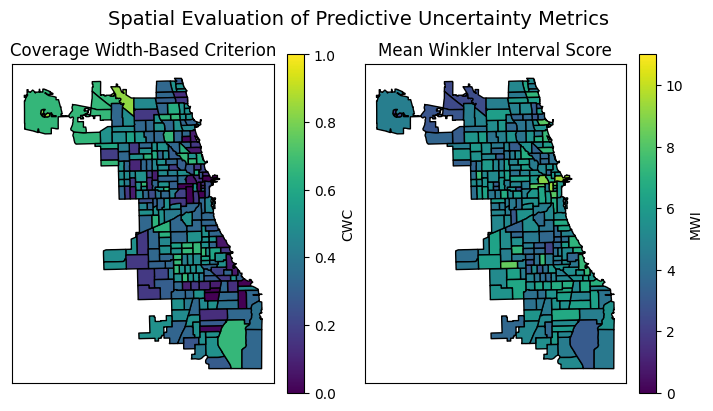

Average Coverage Width-Based Criterion: 0.42 ± 0.22
Average per-cell Mean Winkler Interval Score: 4.77 ± 1.68
Average Coverage Score: 94.43% ± 3.53%
Average Mean Width Score: 3.47 ± 1.38
Average Distance to Interval: 1.19 ± 0.38


In [9]:
plot_geospatial_data_maps(
    gdf_base=gdf[["beat_num", "geometry"]],
    df_list=[df_CWS, df_MWI],
    columns=["Coverage Width-Based Criterion", "Mean Winkler Interval Score"],
    titles=["Coverage Width-Based Criterion", "Mean Winkler Interval Score"],
    cmap="viridis",
    share_colorbar=False,
    colorbar_labels=["CWC","MWI"],
    suptitle="Spatial Evaluation of Predictive Uncertainty Metrics",
    figsize=(7, 4),
    percent_format=[False,False],
    vmax=[1, 11],
    vmin=[0, 0],
    save_path= save_folder / "overall_spatial_eval.pdf"
)


print(f"Average Coverage Width-Based Criterion: { CWS_average :.2f} ± {CWS_std:.2f}")
print(f"Average per-cell Mean Winkler Interval Score: { MWI_average :.2f} ± {MWI_std:.2f}")
print(f"Average Coverage Score: { coverage_average :.2f}% ± {coverage_std:.2f}%")   
print(f"Average Mean Width Score: { width_average :.2f} ± {width_std:.2f}")
print(f"Average Distance to Interval: {distance_interval_average:.2f} ± {distance_interval_std:.2f}")

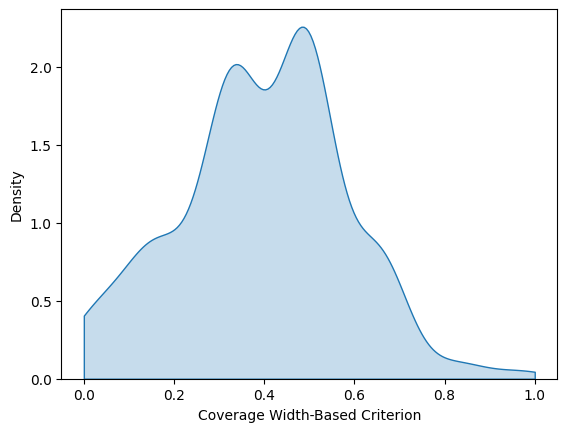

In [10]:
sns.kdeplot(data=df_CWS.reset_index().dropna(), x="Coverage Width-Based Criterion",clip=[0,1],fill=True)
df_CWS.reset_index().dropna().to_csv(save_folder / "CWC_per_cell.csv",index=False)

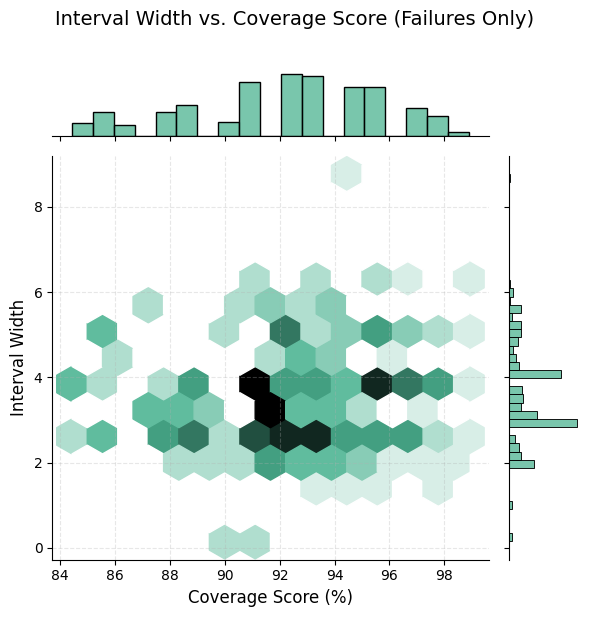

In [11]:
df_metrics = []

for metric_name, metric_data in zip(
    ["Coverage", "Width", "Distance to interval"],
    [in_interval, widths, error]
):
    df_metrics.append(grid_to_dataframe(metric_data, 
                                       coord_to_beat_map, 
                                       value_name=metric_name).set_index(["timestep","row","col","beat"]))

df_metrics = pd.concat(df_metrics,axis=1).reset_index()
df_metrics = df_metrics.merge(pd.concat([df_coverage_score, df_MWI, df_CWS],axis=1).reset_index())
df_metrics.replace({True:"Yes",False:"No"},inplace=True)

df_plot = df_metrics[df_metrics["Coverage"] == "No"].copy()
df_plot["Coverage Score (%)"] = df_plot["Coverage Score"]

# Ajustes del jointplot
joint_kws = dict(gridsize=13, bins=10)
g = sns.jointplot(
    data=df_plot,
    x="Coverage Score (%)",
    y="Width",
    kind="hex",
    joint_kws=joint_kws,
    color="#4CB391"
)

g.figure.suptitle("Interval Width vs. Coverage Score (Failures Only)", fontsize=14, y=1.02)
g.set_axis_labels("Coverage Score (%)", "Interval Width", fontsize=12)
g.ax_joint.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

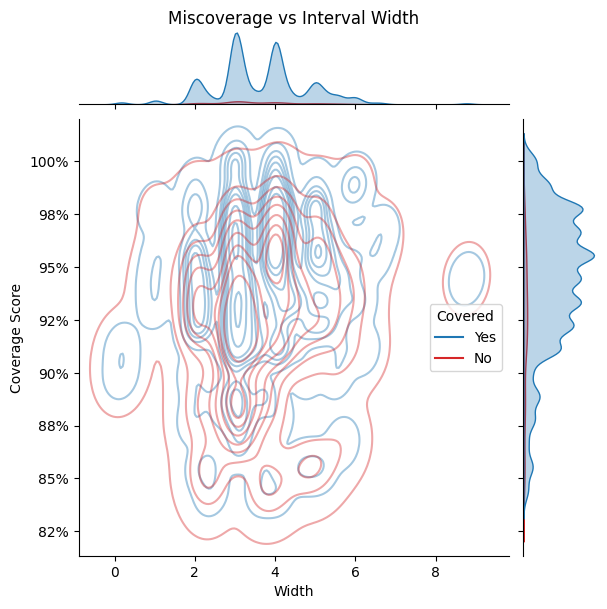

In [12]:
from matplotlib.ticker import PercentFormatter

palette = {
    "Yes": "#1f77b4",  
    "No": "#d62728"  
}

g = sns.jointplot(
    data=df_metrics.dropna(subset="beat"),
    x="Width",
    y="Coverage Score",
    hue="Coverage",
    kind="kde",
    palette=palette,
    fill=False,
    thresh=0.005,
    levels=10,
    common_norm=False,
    marginal_kws=dict(fill=True, alpha=0.3),
    joint_kws=dict(alpha=0.4)
)


g.ax_joint.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

plt.title("Miscoverage vs Interval Width", y=1.2)
sns.move_legend(g.ax_joint, "center right", title='Covered')

plt.tight_layout()
plt.show()


In [13]:
palette = {
    "Neither": "#1f77b4",
    "Both": "#2ca02c",
    "Pred-only": "#9467bd",
    "GT-only": "#d62728"
}

unique, counts = np.unique(overall_hs_class_grid, return_counts=True)
pd.DataFrame( {"Cell Type": unique,"Counts":counts})

,Cell Type,Counts
0,Both,46
1,GT-only,6
2,Neither,232
3,Pred-only,5


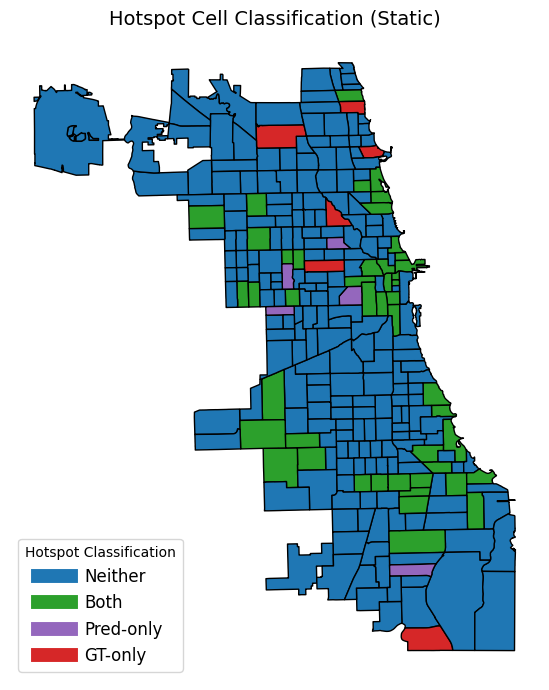

In [14]:
overall_hs_class_df = grid_to_dataframe(overall_hs_class_grid, coord_to_beat_map, value_name="cell_type").set_index(["row","col","beat"]).reset_index()
merged = gdf.merge(
    overall_hs_class_df,
    how="left",
    left_on="beat_num",
    right_on="beat"
).dropna(subset=["cell_type"])

merged["color"] = merged["cell_type"].map(palette)


fig, ax = plt.subplots(figsize=(7,7))
merged.plot(color=merged["color"], edgecolor="black", ax=ax)

for label, color in palette.items():
    ax.plot([], [], color=color, label=label, linewidth=10)
ax.legend(title="Hotspot Classification",  loc='lower left', frameon=True, fontsize=12)
ax.set_axis_off()
plt.title("Hotspot Cell Classification (Static)", fontsize=14)
plt.tight_layout()
plt.savefig(save_folder / "hotspot_classification_static.pdf", bbox_inches='tight')
plt.show()


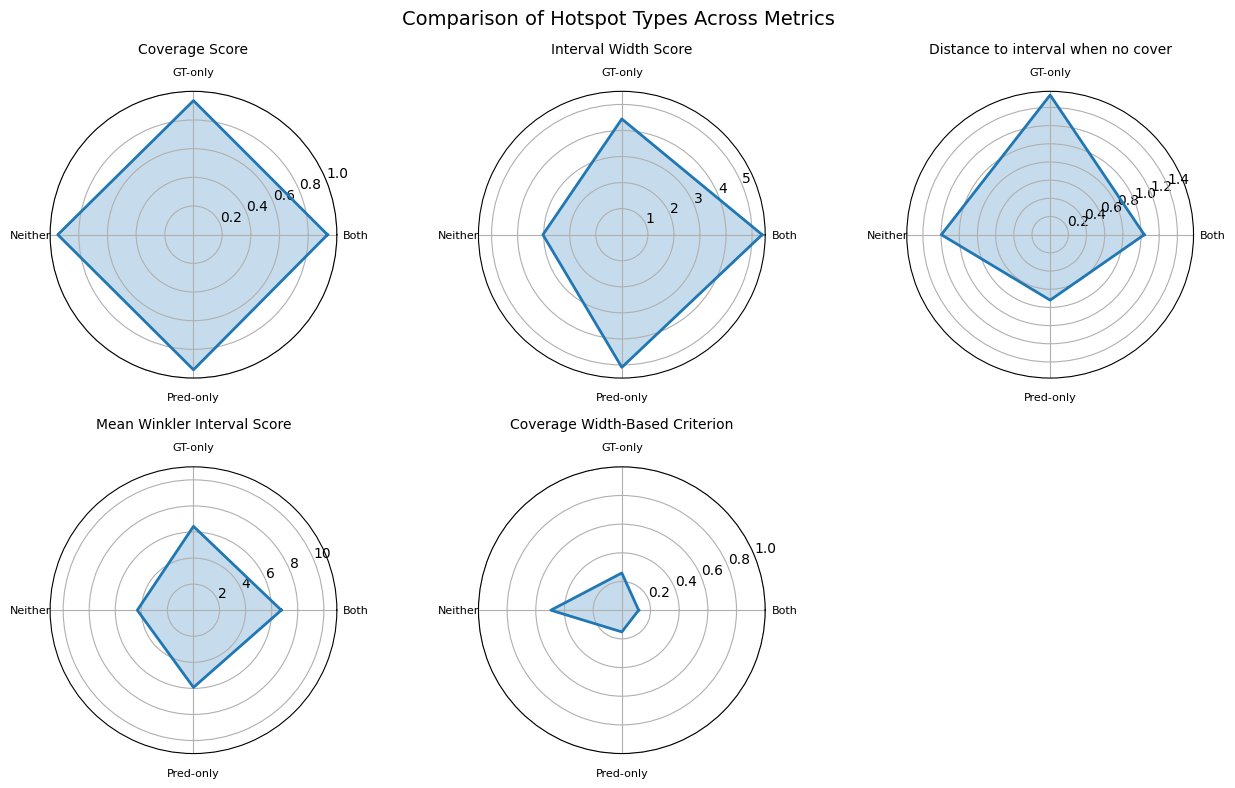

,Coverage Score,Interval Width Score,Distance to interval when no cover,Mean Winkler Interval Score,Coverage Width-Based Criterion
Both,0.934783,5.385749,1.035597,6.736527,0.117311
GT-only,0.935185,4.442593,1.536508,6.434362,0.259568
Neither,0.946504,3.029598,1.197165,4.310473,0.495067
Pred-only,0.942222,5.091111,0.720085,5.923210,0.151481


In [15]:
R=plot_metric_radar_by_hotspot_type(
    results_list=[coverage_results, width_results, error_results, result_mwi, result_cwc],
    metric_names=[
        "Coverage Score",
        "Interval Width Score",
        "Distance to interval when no cover",
        "Mean Winkler Interval Score",
        "Coverage Width-Based Criterion"
    ],
    static=True,  # or False
    title="Comparison of Hotspot Types Across Metrics",
    metric_limits={
        "Coverage Score": (0.0, 1.0),
        "Interval Width Score": (0.0, None),
        "Distance to interval when no cover": (0.0, None), 
        "Mean Winkler Interval Score": (0.0, 11.0),
        "Coverage Width-Based Criterion": (0.0, 1.0)},
    show_tables=True,
    save_path=save_folder / "hotspot_type_comparison_static.pdf"
)


## ⏳ Temporal Behavior of Uncertainty Metrics by Hotspot Type (Static)

This section visualizes how different uncertainty metrics evolve over time for each **hotspot cell type**, based on a static classification (i.e., fixed from the cumulative hotspot map).

### 📈 Metrics Tracked Over Time

The following six subplots are generated using a consistent layout (2 rows × 3 columns):

| Plot | Metric | Description |
|------|--------|-------------|
| 1 | **Coverage Width-Based Criterion (CWC)** | Penalizes intervals that are wide or fail to cover |
| 2 | **Coverage Score (%)** | Proportion of times the interval contains the true value |
| 3 | **Interval Width** | Average width of the prediction interval |
| 4 | **Number of Cells per Hotspot Type (Static)** | Total number of cells classified under each type |
| 5 | **Mean Winkler Interval Score (MWI)** | Combines coverage and width into a single penalty-based metric |
| 6 | **Distance to Interval** | Distance from the true value to the nearest bound when coverage fails |

Each curve represents a hotspot type (e.g., `GT-only`, `Both`, etc.), and colors are assigned using a shared `palette`.

### ⚙️ Parameters

- `mode="static"`: Uses cumulative hotspot classification (`overall_hs_class_df`).
- `palette`: Maps cell types to consistent colors.
- `result_*`: Metric-specific dictionaries returned from `base_analysis`.

### 🧩 Interpretation

This visualization helps to:

- Detect stability or fluctuations in uncertainty metrics across time.
- Understand differences in predictive behavior for each hotspot category.
- Identify temporal trends (e.g., intervals becoming narrower or wider over time, or coverage degrading).

> ✅ This temporal breakdown complements the static radar charts by revealing whether performance varies consistently or sporadically across the evaluation horizon.

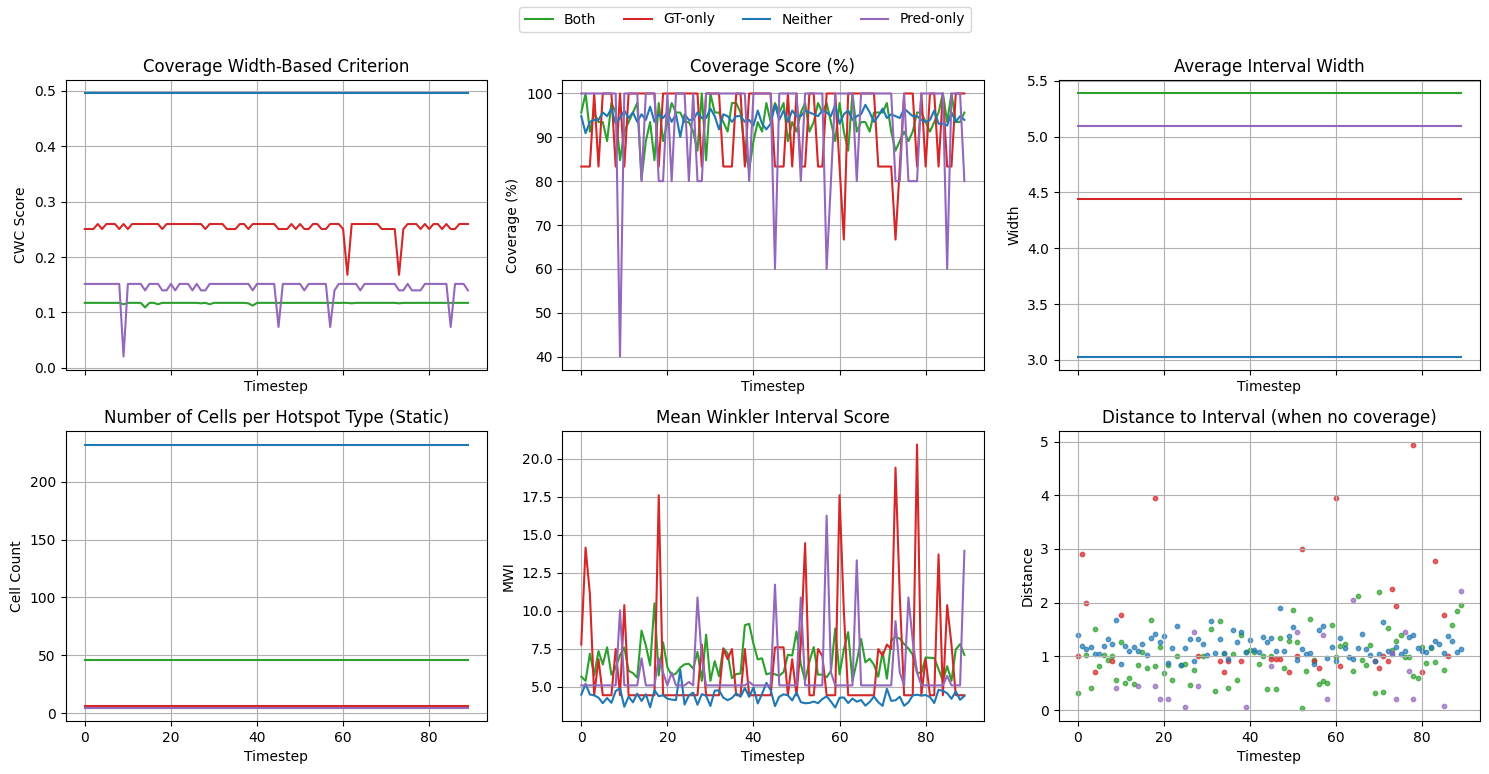

In [16]:
plot_temporal_metrics_over_time(
    result_cwc,
    coverage_results,
    width_results,
    result_mwi,
    error_results,
    mode="static",
    overall_hs_class_df=overall_hs_class_df,
    palette=palette,
    save_path=save_folder / "temporal_metrics_over_time_static.pdf",
)


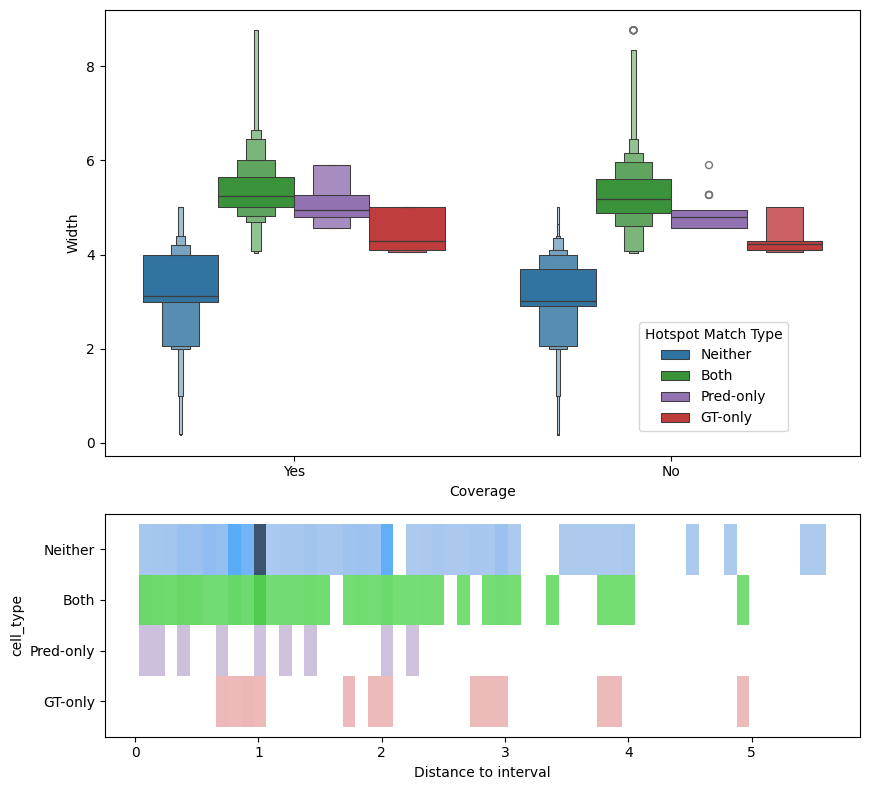

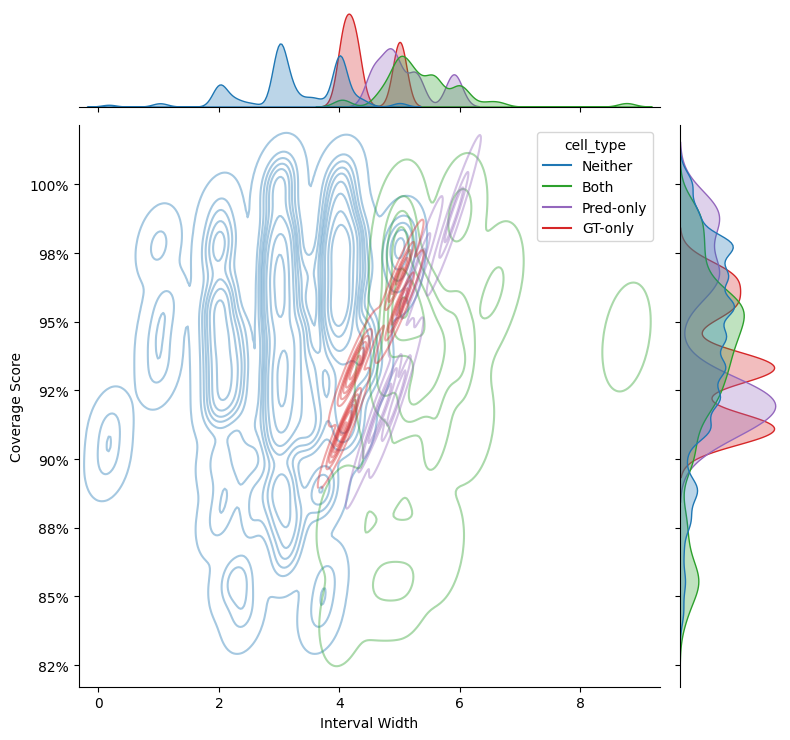

In [17]:
hue_order = ["Neither", "Both", "Pred-only", "GT-only"]

# Prepare plotting DataFrame
df_plot = df_metrics.merge(overall_hs_class_df,on=["row","col","beat"]).dropna(subset="beat")

# Main plot: Boxenplot + stacked histogram
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 8), sharex=False, gridspec_kw={"height_ratios": [2, 1]})

# Boxenplot: Interval width per coverage and hotspot type
sns.boxenplot(
    data=df_plot,
    x="Coverage", y="Width",
    hue="cell_type",
    palette=palette,
    hue_order=hue_order,
    ax=ax1
)
# ax1.set_title("Interval Width by Coverage and Hotspot Type")
ax1.legend_.remove()

# Histogram: Distance when outside interval
df_errors = df_plot[df_plot["Coverage"] == "No"].copy()
df_errors["cell_type"] = pd.Categorical(df_errors["cell_type"], categories=hue_order, ordered=True)

sns.histplot(
    df_errors,
    y="cell_type",
    x="Distance to interval",
    hue="cell_type",
    ax=ax2,
    legend=False,
    hue_order=hue_order,
    palette=palette,
)

# Shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title="Hotspot Match Type", bbox_to_anchor=(0.8, 0.6), frameon=True)

plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(save_folder / "interval_width_by_match_static.pdf", format="pdf", bbox_inches="tight", dpi=300)
fig.savefig(save_folder / "interval_width_by_match_static.png", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

# --- Joint KDE Plot: Misscoverage vs. Interval Width
g = sns.JointGrid(
    data=df_plot,
    x="Width",
    y="Coverage Score",
    hue="cell_type",
    palette=palette,
    hue_order=hue_order,
    height=8
)

g.plot_joint(sns.kdeplot, fill=False, alpha=0.4, thresh=0.005)
g.plot_marginals(sns.kdeplot, common_norm=False, fill=True, alpha=0.3)
g.ax_joint.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
# g.figure.suptitle("Misscoverage vs. Interval Width by Hotspot Type", fontsize=14)
g.set_axis_labels("Interval Width", "Coverage Score")
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.92)
fig.savefig(save_folder / "2d_interval_width_by_match_static.pdf", format="pdf", bbox_inches="tight", dpi=300)
fig.savefig(save_folder / "2d_interval_width_by_match_static.png", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [18]:
unique, counts = np.unique(time_step_hs_class_grid, return_counts=True)
pd.DataFrame( {"Cell Type": unique,"Counts":counts})

,Cell Type,Counts
0,Both,1302
1,GT-only,1508
2,Neither,19912
3,Pred-only,3288


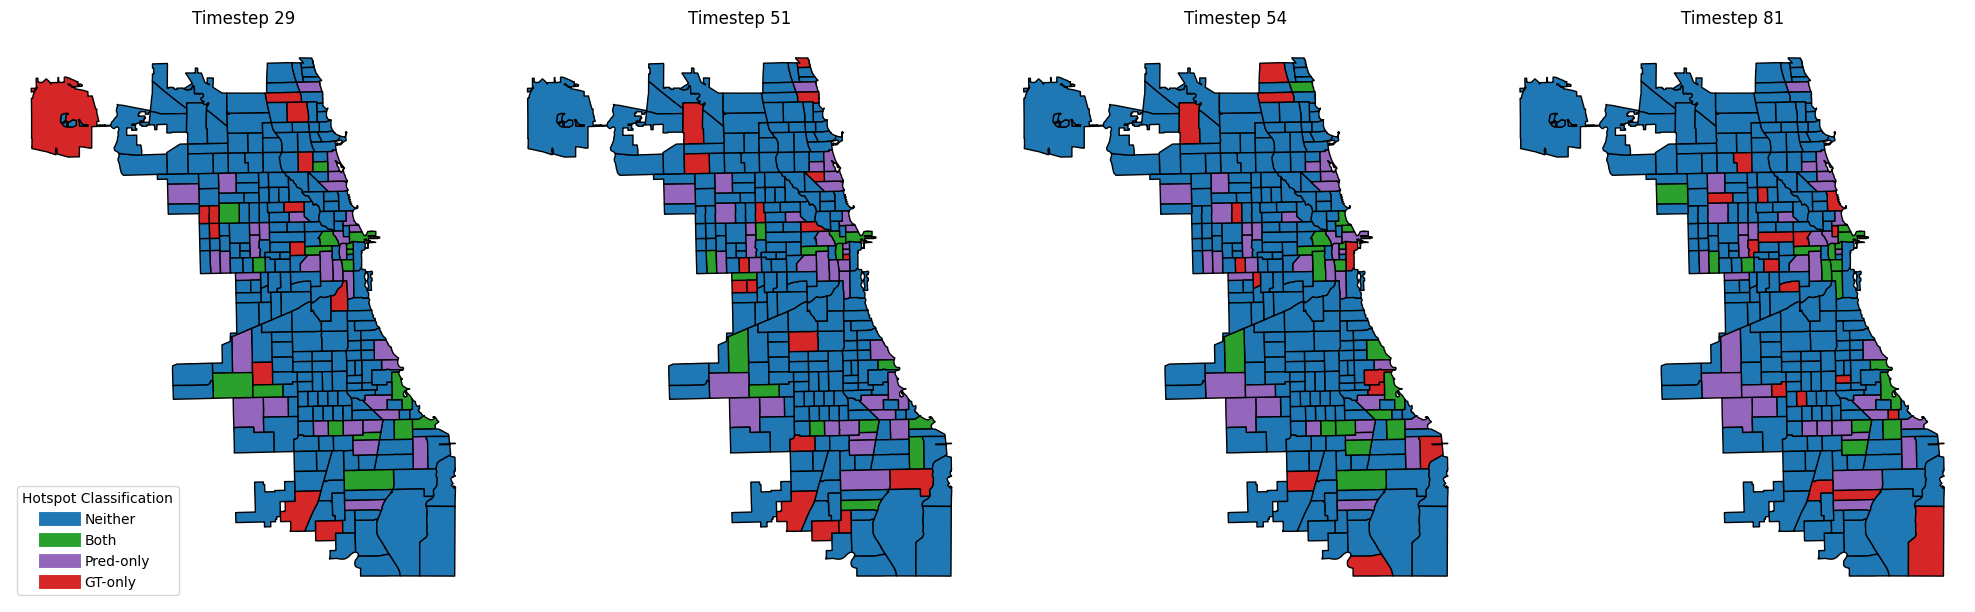

In [19]:
time_step_hs_class_df = grid_to_dataframe(time_step_hs_class_grid, coord_to_beat_map, value_name="cell_type").set_index(["timestep","row","col","beat"]).reset_index()

# Sample 4 random timesteps
random_times = sorted(np.random.choice(time_step_hs_class_df["timestep"].unique(), 4, replace=False))

# Create 1 row x 4 columns figure
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, time in enumerate(random_times):
    ax = axes[i]

    # Merge classification for selected timestep
    merged = gdf.merge(
        time_step_hs_class_df[time_step_hs_class_df["timestep"] == time],
        how="left",
        left_on="beat_num",
        right_on="beat"
    ).dropna(subset=["cell_type"])

    merged["color"] = merged["cell_type"].map(palette)

    # Plot
    merged.plot(color=merged["color"], edgecolor="black", ax=ax)
    ax.set_title(f"Timestep {time}", fontsize=12)
    ax.set_axis_off()

# Add a single legend on the first axis
handles = [plt.Line2D([0], [0], color=color, linewidth=10) for label, color in palette.items()]
labels = list(palette.keys())
axes[0].legend(handles, labels, title="Hotspot Classification", loc="lower left", frameon=True, fontsize=10)

# fig.suptitle("Hotspot Cell Classification Over Time", fontsize=16)
plt.tight_layout()
fig.savefig(save_folder / "hotspot_classification_over_time.pdf", bbox_inches='tight',dpi=300)
fig.savefig(save_folder / "hotspot_classification_over_time.png", bbox_inches='tight',dpi=300)
plt.show()

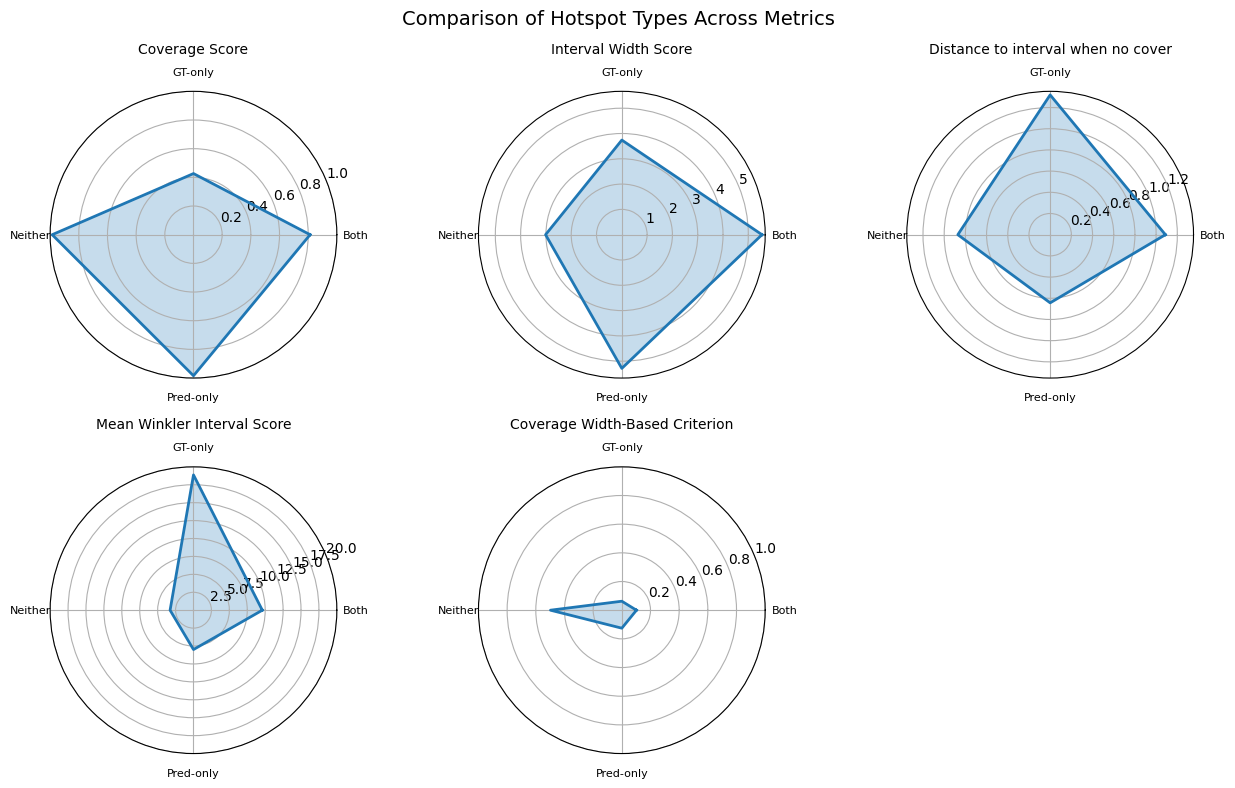

,Coverage Score,Interval Width Score,Distance to interval when no cover,Mean Winkler Interval Score,Coverage Width-Based Criterion
Both,0.813364,5.540621,1.087426,9.599676,0.102036
GT-only,0.426393,3.740127,1.319049,18.872458,0.062607
Neither,0.985587,3.014107,0.871196,3.265245,0.497649
Pred-only,0.983881,5.284097,0.643187,5.491450,0.125536


,Coverage Score,Interval Width Score,Distance to interval when no cover,Mean Winkler Interval Score,Coverage Width-Based Criterion
Both,0.813364,5.540621,1.087426,9.599676,0.102036
GT-only,0.426393,3.740127,1.319049,18.872458,0.062607
Neither,0.985587,3.014107,0.871196,3.265245,0.497649
Pred-only,0.983881,5.284097,0.643187,5.491450,0.125536


In [20]:
plot_metric_radar_by_hotspot_type(
    results_list=[coverage_results, width_results, error_results, result_mwi, result_cwc],
    metric_names=[
        "Coverage Score",
        "Interval Width Score",
        "Distance to interval when no cover",
        "Mean Winkler Interval Score",
        "Coverage Width-Based Criterion"
    ],
    static=False,
    metric_limits={
        "Coverage Score": (0.0, 1.0),
        "Interval Width Score": (0.0, None),
        "Distance to interval when no cover": (0.0, None), 
        "Mean Winkler Interval Score": (0.0, 20.0),
        "Coverage Width-Based Criterion": (0.0, 1.0)},
    show_tables=True,
    save_path=save_folder / "hotspot_type_comparison_dynamic.pdf"
)


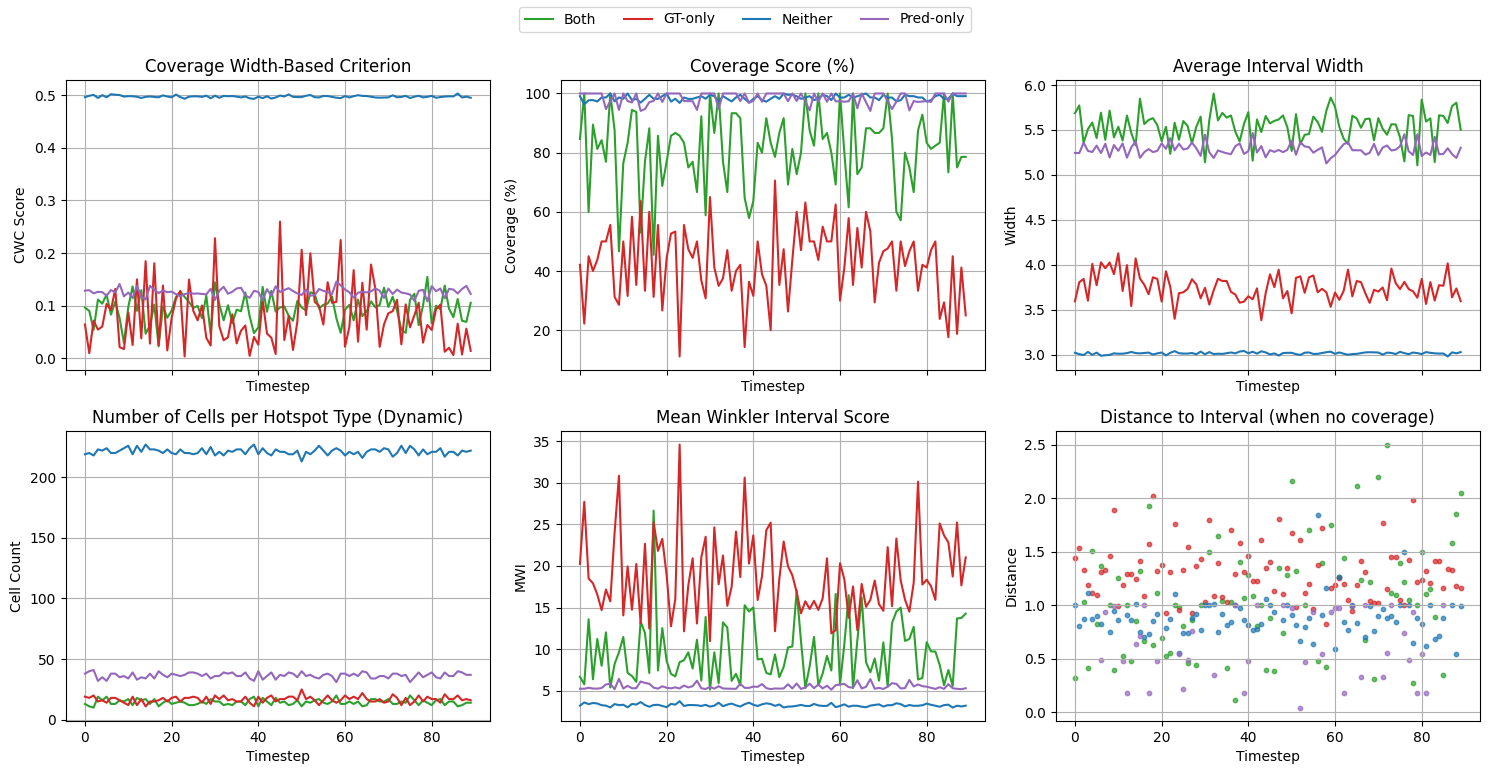

In [21]:
plot_temporal_metrics_over_time(
    result_cwc,
    coverage_results,
    width_results,
    result_mwi,
    error_results,
    mode="dynamic",
    time_step_hs_class_df=time_step_hs_class_df,
    palette=palette,
    save_path=save_folder / "temporal_metrics_over_time_dynamic.pdf"
)

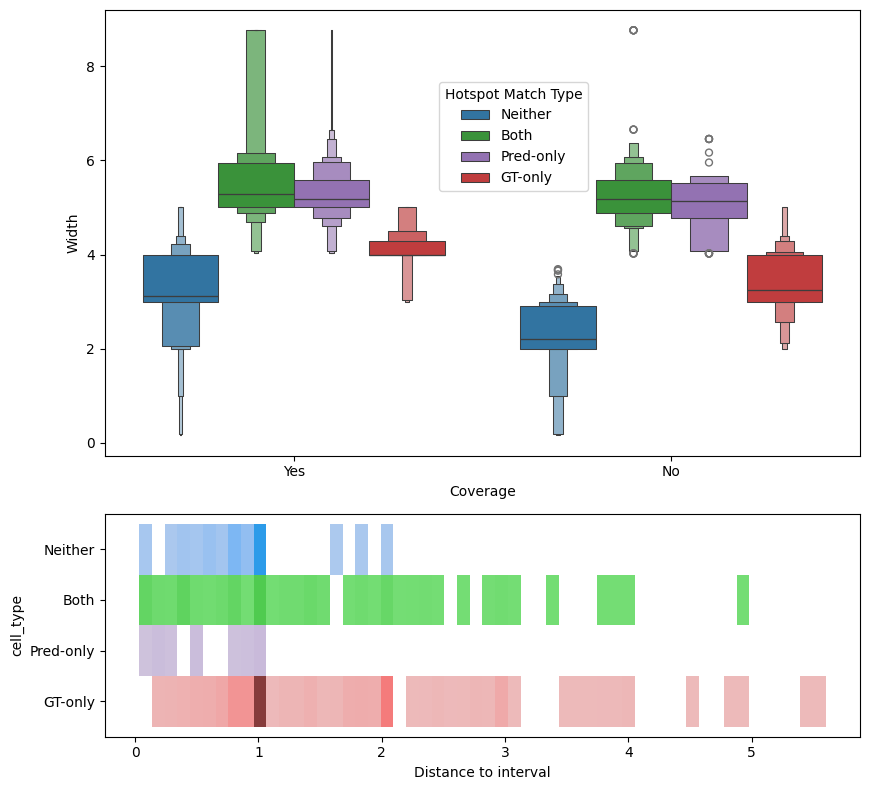

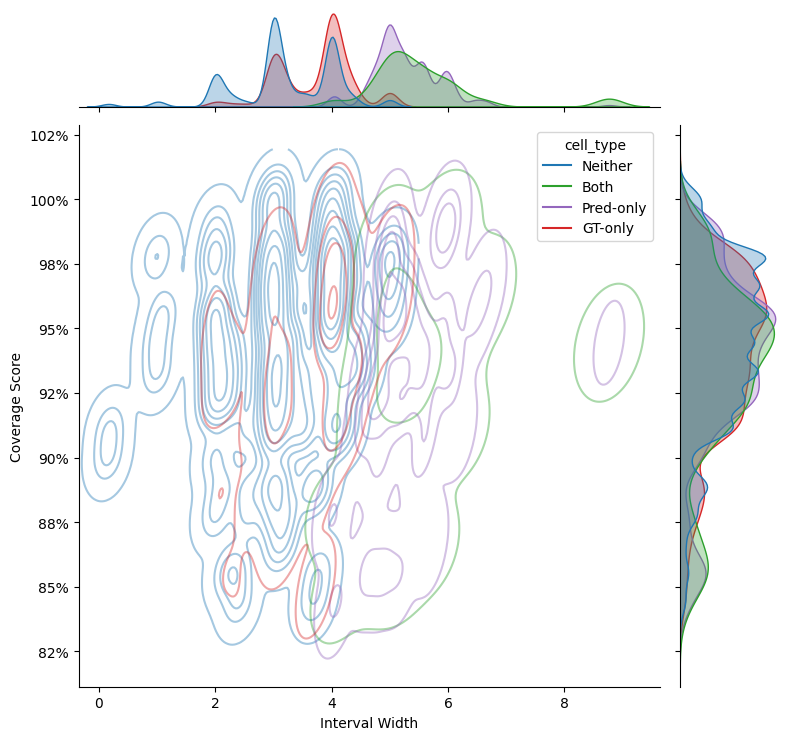

In [22]:
hue_order = ["Neither", "Both", "Pred-only", "GT-only"]

# Prepare plotting DataFrame
df_plot = df_metrics.merge(time_step_hs_class_df,on=["timestep","row","col","beat"]).dropna(subset="beat")

# Main plot: Boxenplot + stacked histogram
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 8), sharex=False, gridspec_kw={"height_ratios": [2, 1]})

# Boxenplot: Interval width per coverage and hotspot type
sns.boxenplot(
    data=df_plot,
    x="Coverage", y="Width",
    hue="cell_type",
    palette=palette,
    hue_order=hue_order,
    ax=ax1
)
# ax1.set_title("Interval Width by Coverage and Hotspot Type")
ax1.legend_.remove()

# Histogram: Distance when outside interval
df_errors = df_plot[df_plot["Coverage"] == "No"].copy()
df_errors["cell_type"] = pd.Categorical(df_errors["cell_type"], categories=hue_order, ordered=True)

sns.histplot(
    df_errors,
    y="cell_type",
    x="Distance to interval",
    hue="cell_type",
    ax=ax2,
    legend=False,
    hue_order=hue_order,
    palette=palette,
)

# Shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title="Hotspot Match Type", bbox_to_anchor=(0.6, 0.9), frameon=True)

plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(save_folder / "interval_width_by_match_dynamic.pdf", format="pdf", bbox_inches="tight", dpi=300)
fig.savefig(save_folder / "interval_width_by_match_dynamic.png", format="png", bbox_inches="tight", dpi=300)
plt.show()

# --- Joint KDE Plot: Misscoverage vs. Interval Width
g = sns.JointGrid(
    data=df_plot,
    x="Width",
    y="Coverage Score",
    hue="cell_type",
    palette=palette,
    hue_order=hue_order,
    height=8
)

g.plot_joint(sns.kdeplot, fill=False, alpha=0.4, thresh=0.005)
g.plot_marginals(sns.kdeplot, common_norm=False, fill=True, alpha=0.3)
g.ax_joint.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
# g.figure.suptitle("Misscoverage vs. Interval Width by Hotspot Type", fontsize=14)
g.set_axis_labels("Interval Width", "Coverage Score")
g.figure.tight_layout()
g.figure.subplots_adjust(top=0.92)
g.savefig(save_folder / "2d_interval_width_by_match_dynamic.pdf", format="pdf", bbox_inches="tight", dpi=300)
g.savefig(save_folder / "2d_interval_width_by_match_dynamic.png", format="png", bbox_inches="tight", dpi=300)
plt.show()

In [23]:
plot_weighted_cwc_series(WH_CWC,save_path=save_folder / "weighted_cwc_series.pdf")

KeyError: 'static_series'

In [ ]:
pd.DataFrame.from_dict({ key: WH_CWC[key] for key in ["global_value","static_weighted","dynamic_weighted"] },
                       orient='index', 
                       columns=["WH-CWC"]).to_csv(save_folder / "WH-CWC.csv")